# Notebook to make Figures 7, 8, and 9: Partial PPCs and Split PCs (traces and p-values)

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D

import sys
sys.path.append('../utils')
import plot_utils 

## Setup

Load data

In [2]:
# Predicted vs. Observed PPC traces 
zp_partial_predobs = np.load('../data/PPC_traces_partial_zp.npz', allow_pickle=True)['arr_0'].item()
std_partial_predobs = np.load('../data/PPC_traces_partial_std.npz', allow_pickle=True)['arr_0'].item()
split_predobs = np.load('../data/PPC_traces_split.npz', allow_pickle=True)['arr_0'].item()

Get fraction underpredicted

In [3]:
# May take a minute
zp_partial_underpredicted = {
    ll:plot_utils.fraction_underpredicted(zp_partial_predobs[ll], ['costheta'])[1] for ll in zp_partial_predobs.keys()
}
std_partial_underpredicted = {
    ll:plot_utils.fraction_underpredicted(std_partial_predobs[ll], ['costheta'])[1] for ll in std_partial_predobs.keys()
}
split_underpredicted = {
    ll:plot_utils.fraction_underpredicted(split_predobs[ll], ['costheta'], ncut=6)[1] for ll in split_predobs.keys()
}

Calculate test statistics $T$ and associated $p$-values

In [4]:
# Calculate test statistics
T_dict_zp_partial = plot_utils.get_test_statistics(zp_partial_predobs)
T_dict_std_partial = plot_utils.get_test_statistics(std_partial_predobs)
T_dict_split = plot_utils.get_test_statistics(split_predobs)

## Make PPC traces portion of figures

Plotting labels, aesthetics, etc.

In [5]:
param='costheta'
xticks = [-1, -.5, 0, .5, 1]
yticks = [0, 0.25, 0.5, 0.75, 1]
ntraces = 100
lims = [-1,1]

posts = list(plot_utils.run_labels_short.keys())

TITLE_FONTSIZE = 18
AXISLABEL_FONTSIZE = 18
TICKLABEL_FONTSIZE = 15.5

plt.rcParams.update({
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXISLABEL_FONTSIZE,
    "xtick.labelsize": TICKLABEL_FONTSIZE,
    "ytick.labelsize": TICKLABEL_FONTSIZE,
})

Partial PPC with $T_0=\frac{N(\cos\theta\in[-0.33, 0.33])}{N(\cos\theta\in[0.33, 1])}$

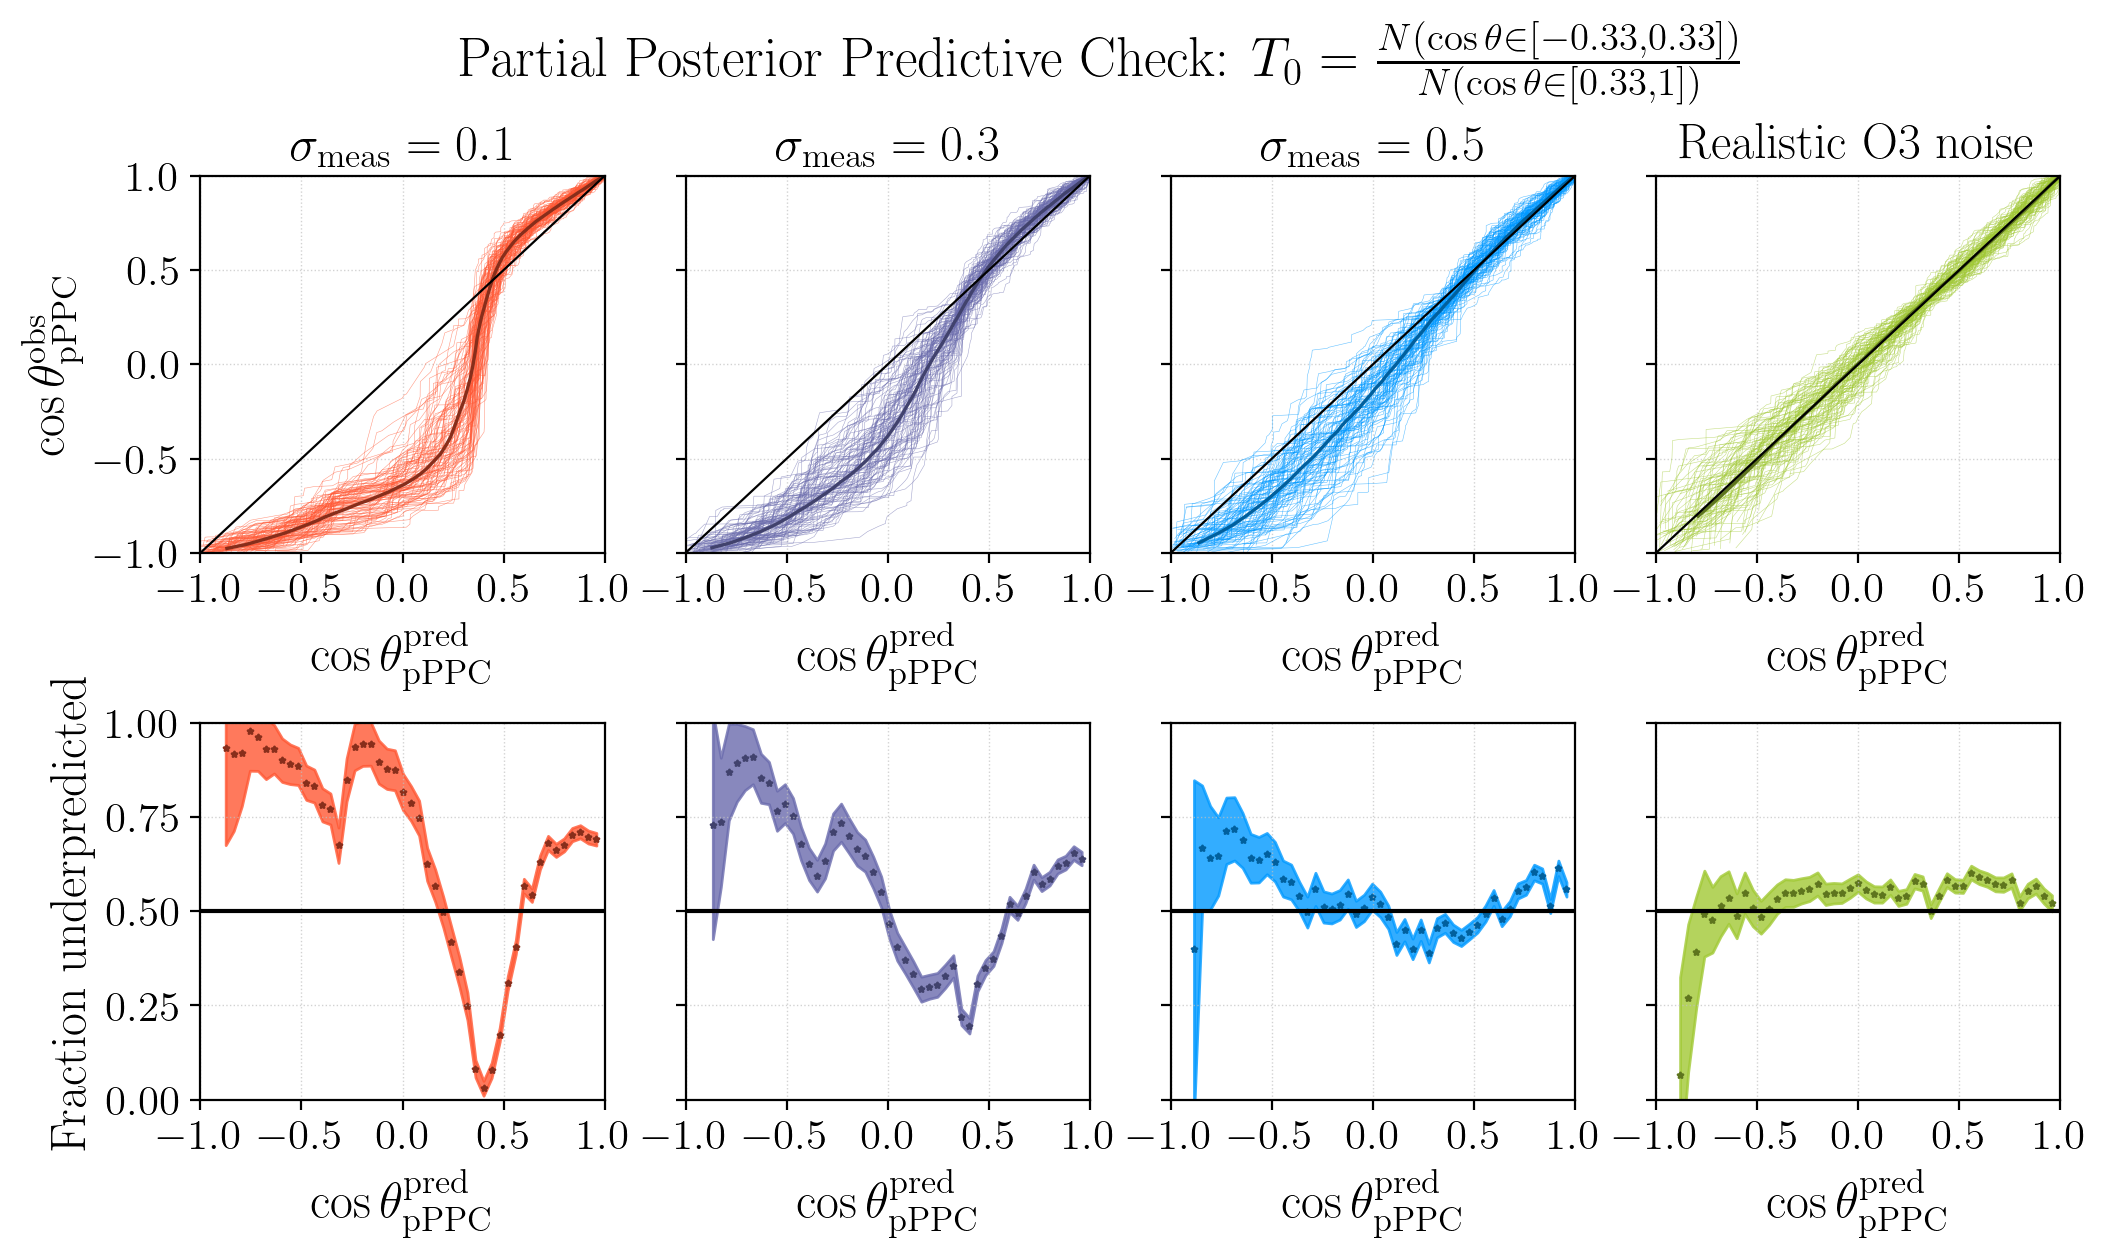

In [6]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12,6), sharey='row')

# top row: traces
a = ax[0]
for j, post in enumerate(posts):
    a[j].set_xlabel(r'$\cos\theta^{\rm pred}_{\rm pPPC}$')
    a[j].set_xticks(xticks)
    a[j].set_yticks(xticks)
    a[j].set_xlim(*lims)
    a[j].set_ylim(*lims)
    a[j].set_title(plot_utils.run_labels_short[post])
    a[j].grid()

    inds = np.arange(0, len(zp_partial_predobs[post]['predicted']['costheta1']), 1)
    randinds = np.random.choice(inds, size=ntraces, replace=False)

    for ind in randinds:
        pred = np.sort(zp_partial_predobs[post]['predicted'][param][ind])
        obs = np.sort(zp_partial_predobs[post]['observed'][param][ind])

        a[j].plot(pred, obs, color=plot_utils.run_colors[post], lw=.2, alpha=.6)
    
    allobs, pred_avgs = plot_utils.average_curve(zp_partial_predobs[post], param)
    a[j].plot(pred_avgs, allobs, lw=1.2, color=plot_utils.run_colors_darker[post])
    a[j].plot(lims, lims, lw=.8, color='black')

# bottom row: fraction underpredicted
a = ax[1]
for j, post in enumerate(posts):
    a[j].set_xlabel(r'$\cos\theta^{\rm pred}_{\rm pPPC}$')
    a[j].set_xticks(xticks)
    a[j].set_xlim(lims)
    a[j].set_ylim(0, 1)
    a[j].grid()
    
    x = zp_partial_underpredicted[post][param]['xs'][1:-1]
    y = zp_partial_underpredicted[post][param]['fraction'][1:-1]
    err = 1/np.sqrt(zp_partial_underpredicted[post][param]['N'][1:-1])

    a[j].plot(lims, [0.5,0.5], color='black')
    a[j].fill_between(x, y+err, y-err, alpha=0.8, color=plot_utils.run_colors[post])
    a[j].scatter(x, y, color=plot_utils.run_colors_darker[post], s=3.5, marker='*')
    
ax[0][0].set_ylabel(r'$\cos\theta^{\rm obs}_{\rm pPPC}$');
ax[1][0].set_ylabel(r'Fraction underpredicted');

fig.subplots_adjust(hspace=.45, wspace=.2)

plt.suptitle(
    r'Partial Posterior Predictive Check: $T_0=\frac{N(\cos\theta\in[-0.33, 0.33])}{N(\cos\theta\in[0.33, 1])}$',
    fontsize=TITLE_FONTSIZE+2, y=1.01
);
plt.savefig('figure_07a.png', dpi=300, bbox_inches='tight')

Partial PPC with $T_0$ = standard deviation

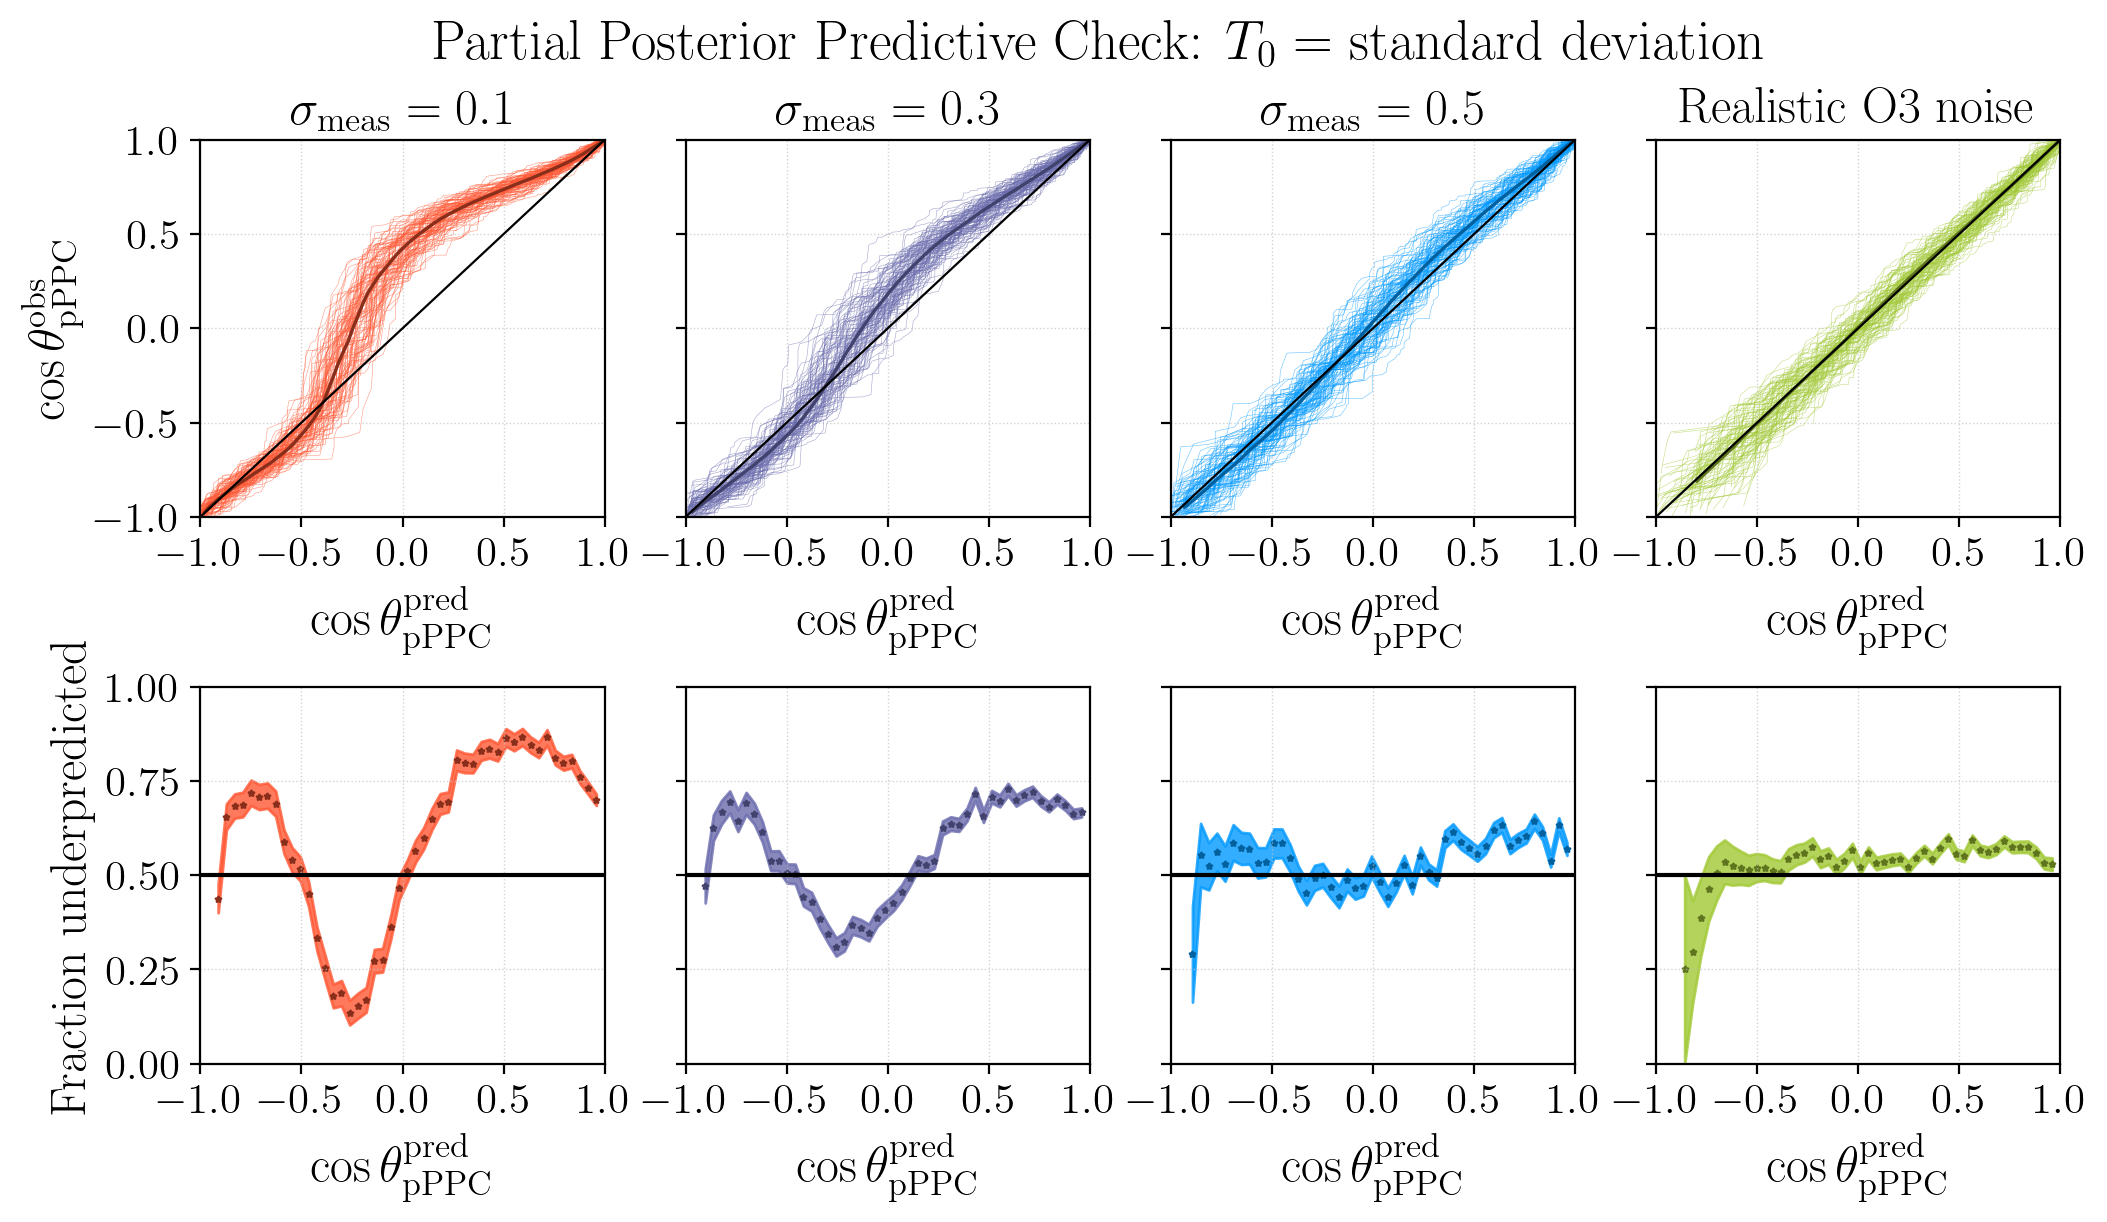

In [7]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12,6), sharey='row')

# top row: traces
a = ax[0]
for j, post in enumerate(posts):
    a[j].set_xlabel(r'$\cos\theta^{\rm pred}_{\rm pPPC}$')
    a[j].set_xticks(xticks)
    a[j].set_yticks(xticks)
    a[j].set_xlim(*lims)
    a[j].set_ylim(*lims)
    a[j].set_title(plot_utils.run_labels_short[post])
    a[j].grid()

    inds = np.arange(0, len(std_partial_predobs[post]['predicted']['costheta1']), 1)
    randinds = np.random.choice(inds, size=ntraces, replace=False)

    for ind in randinds:
        pred = np.sort(std_partial_predobs[post]['predicted'][param][ind])
        obs = np.sort(std_partial_predobs[post]['observed'][param][ind])

        a[j].plot(pred, obs, color=plot_utils.run_colors[post], lw=.2, alpha=.6)
    
    allobs, pred_avgs = plot_utils.average_curve(std_partial_predobs[post], param)
    a[j].plot(pred_avgs, allobs, lw=1.2, color=plot_utils.run_colors_darker[post])
    a[j].plot(lims, lims, lw=.8, color='black')

# bottom row: fraction underpredicted
a = ax[1]
for j, post in enumerate(posts):
    a[j].set_xlabel(r'$\cos\theta^{\rm pred}_{\rm pPPC}$')
    a[j].set_xticks(xticks)
    a[j].set_xlim(lims)
    a[j].set_ylim(0, 1)
    a[j].grid()
    
    x = std_partial_underpredicted[post][param]['xs'][1:-1]
    y = std_partial_underpredicted[post][param]['fraction'][1:-1]
    err = 1/np.sqrt(std_partial_underpredicted[post][param]['N'][1:-1])

    a[j].plot(lims, [0.5,0.5], color='black')
    a[j].fill_between(x, y+err, y-err, alpha=0.8, color=plot_utils.run_colors[post])
    a[j].scatter(x, y, color=plot_utils.run_colors_darker[post], s=3.5, marker='*')
    
ax[0][0].set_ylabel(r'$\cos\theta^{\rm obs}_{\rm pPPC}$');
ax[1][0].set_ylabel(r'Fraction underpredicted');

fig.subplots_adjust(hspace=.45, wspace=.2)

plt.suptitle(
    r'Partial Posterior Predictive Check: $T_0=$ standard deviation',
    fontsize=TITLE_FONTSIZE+2
);
plt.savefig('figure_08a.png', dpi=300, bbox_inches='tight')

Split PC

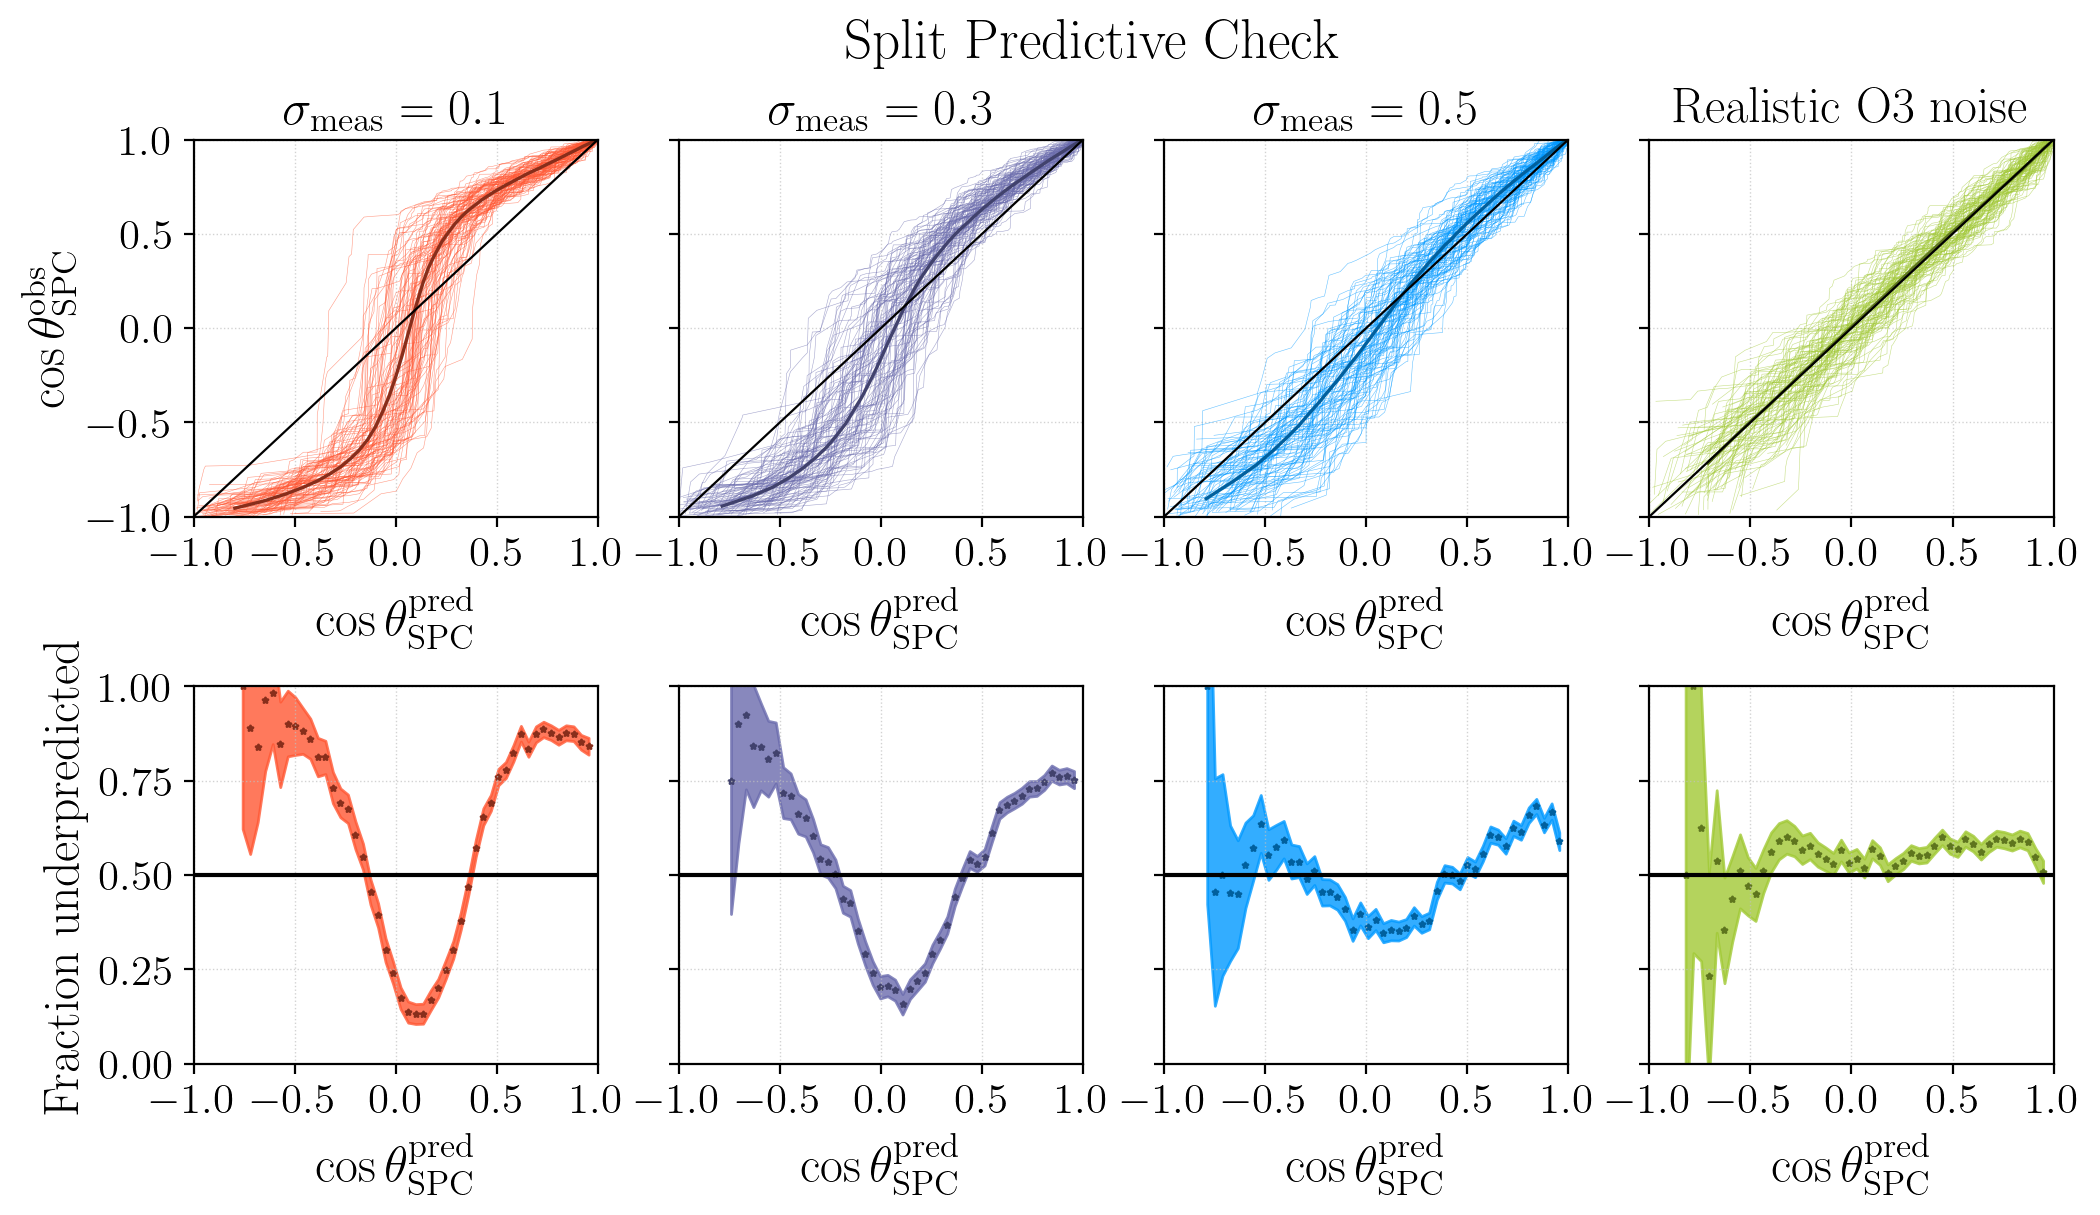

In [8]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(12,6), sharey='row')

# top row: traces
a = ax[0]
for j, post in enumerate(posts):
    a[j].set_xlabel(r'$\cos\theta^{\rm pred}_{\rm SPC}$')
    a[j].set_xticks(xticks)
    a[j].set_yticks(xticks)
    a[j].set_xlim(*lims)
    a[j].set_ylim(*lims)
    a[j].set_title(plot_utils.run_labels_short[post])
    a[j].grid()

    inds = np.arange(0, len(split_predobs[post]['predicted']['costheta1']), 1)
    randinds = np.random.choice(inds, size=ntraces, replace=False)

    for ind in randinds:
        pred = np.sort(split_predobs[post]['predicted'][param][ind])
        obs = np.sort(split_predobs[post]['observed'][param][ind])

        a[j].plot(pred, obs, color=plot_utils.run_colors[post], lw=.2, alpha=.6)
    
    allobs, pred_avgs = plot_utils.average_curve(split_predobs[post], param)
    a[j].plot(pred_avgs, allobs, lw=1.2, color=plot_utils.run_colors_darker[post])
    a[j].plot(lims, lims, lw=.8, color='black')

# bottom row: fraction underpredicted
a = ax[1]
for j, post in enumerate(posts):
    a[j].set_xlabel(r'$\cos\theta^{\rm pred}_{\rm SPC}$')
    a[j].set_xticks(xticks)
    a[j].set_xlim(lims)
    a[j].set_ylim(0, 1)
    a[j].grid()
    
    x = split_underpredicted[post][param]['xs'][1:-1]
    y = split_underpredicted[post][param]['fraction'][1:-1]
    err = 1/np.sqrt(split_underpredicted[post][param]['N'][1:-1])

    a[j].plot(lims, [0.5,0.5], color='black')
    a[j].fill_between(x, y+err, y-err, alpha=0.8, color=plot_utils.run_colors[post])
    a[j].scatter(x, y, color=plot_utils.run_colors_darker[post], s=3.5, marker='*')
    
ax[0][0].set_ylabel(r'$\cos\theta^{\rm obs}_{\rm SPC}$');
ax[1][0].set_ylabel(r'Fraction underpredicted');

fig.subplots_adjust(hspace=.45, wspace=.2)

plt.suptitle(r'Split Predictive Check', fontsize=TITLE_FONTSIZE+2);

plt.savefig('figure_09a.png', dpi=300, bbox_inches='tight')

## Make p-value portion of figures

More plotting aesthetic set ups

In [9]:
run_orders = {
    'gaussian_likelihood_sigma_0.1':2,
    'gaussian_likelihood_sigma_0.3':1,
    'gaussian_likelihood_sigma_0.5':0,
    'bilby_likelihood':-1
}
text_kws = dict(verticalalignment='top', zorder=6, fontsize=12,
                    bbox=dict(boxstyle='round,pad=0.1', ec='white', fc='white', alpha=0.95))

Partial PPC with $T_0=\frac{N(\cos\theta\in[-0.33, 0.33])}{N(\cos\theta\in[0.33, 1])}$

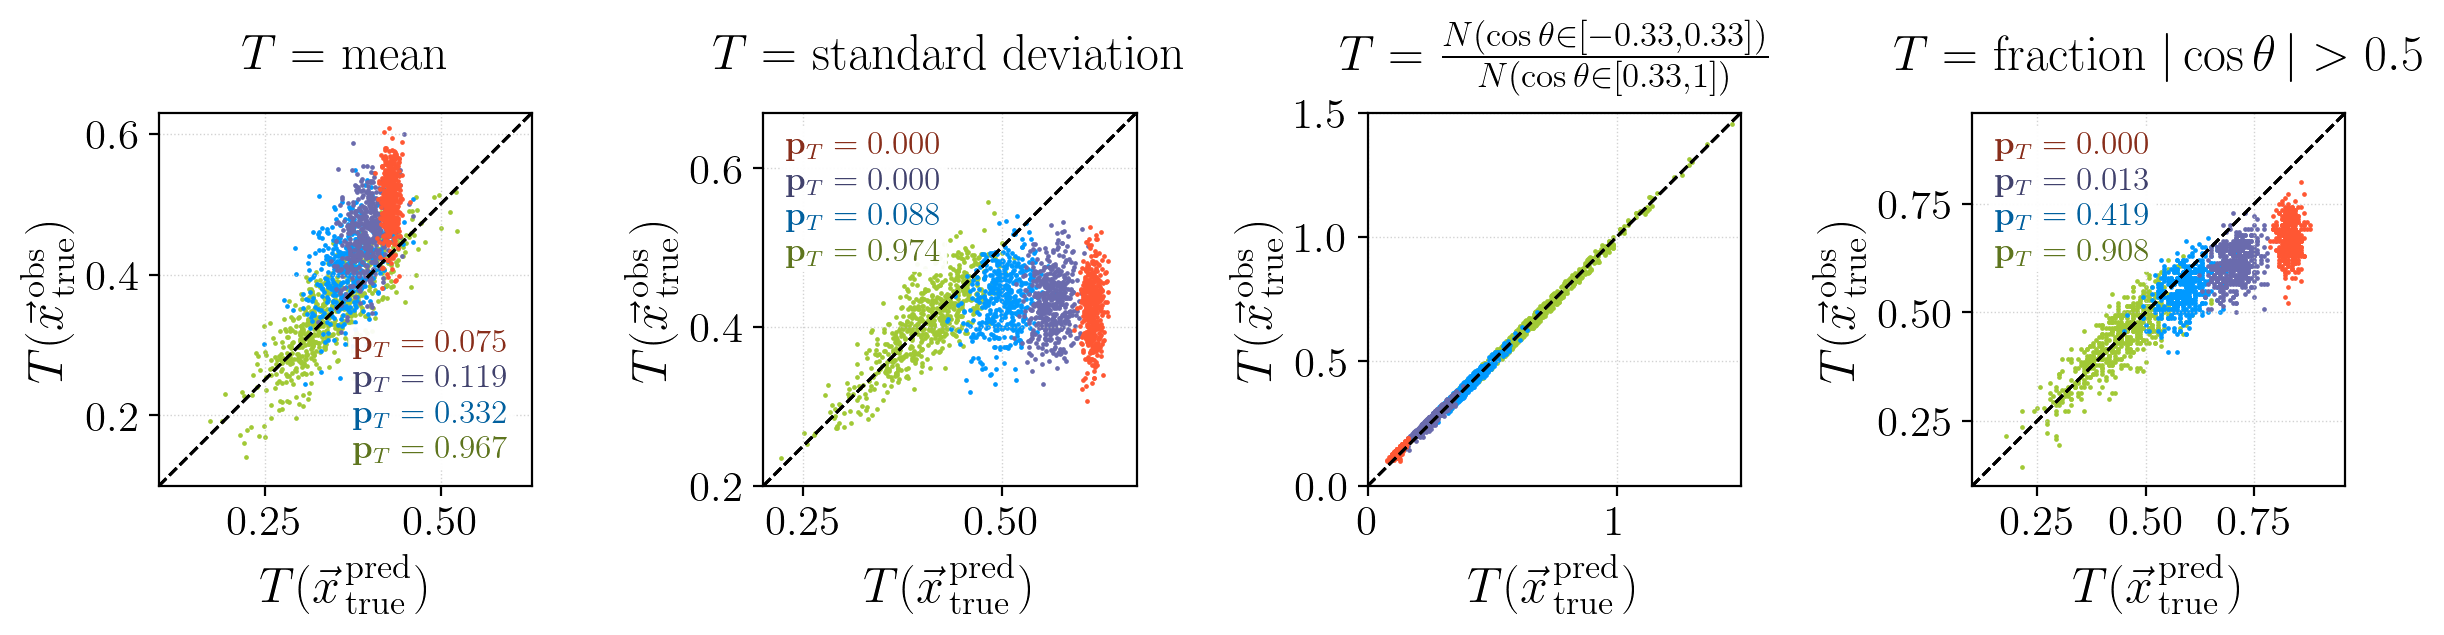

In [10]:
bounds_dict = {
    'mean':[0.1,0.63],
    'standard deviation':[0.2,0.67], 
    plot_utils.zp_title:[0,1.5],
    r'fraction $|\cos\theta\,|>0.5$':[0.1,0.96]
}

fig, axes = plt.subplots(1,4,figsize=(12,3))

for j, (run, T_dict) in enumerate(T_dict_zp_partial.items()):
    color = plot_utils.run_colors[run]
    pcolor = plot_utils.run_colors_darker[run]
    run_label = plot_utils.run_labels[run]
    
    for i, k in enumerate(T_dict.keys()): 

        ax_top = axes[i]
        ax_top.scatter(T_dict[k]['T'], T_dict[k]['Trep'], s=0.5, 
                   color=color, label=run_label, zorder=run_orders[run])
        
        diag = bounds_dict[k]
        ax_top.plot(diag, diag, color='k', lw=1, ls='--', zorder=5)
        ax_top.set_xlim(*diag)
        ax_top.set_ylim(*diag)
    
        p = T_dict[k]['pvalue']

        if i != 2:
            if i == 0: 
                ax_top.text(0.52, 0.42-j*0.095, fr'$\mathbf{{p}}_T={p:.3f}$', 
                        transform=ax_top.transAxes, color=pcolor, **text_kws)
            else:
                ax_top.text(0.06, 0.95-j*0.095, fr'$\mathbf{{p}}_T={p:.3f}$', 
                        transform=ax_top.transAxes, color=pcolor, **text_kws)
            
        ax_top.set_xlabel(r'$T(\vec{x}^{\,\mathrm{pred}}_{\,\mathrm{true}})$')
        ax_top.set_ylabel(r'$T(\vec{x}^{\,\mathrm{obs}}_{\,\mathrm{true}})$')
        ax_top.set_title(fr'$T=$ {k}',y=1.07)
        ax_top.set_box_aspect(1)

for ax in axes.flatten(): 
    ax.grid()
plt.tight_layout()

plt.savefig('figure_07b.png', dpi=300, bbox_inches='tight')
plt.show()

Partial PPC with $T_0$ = standard deviation

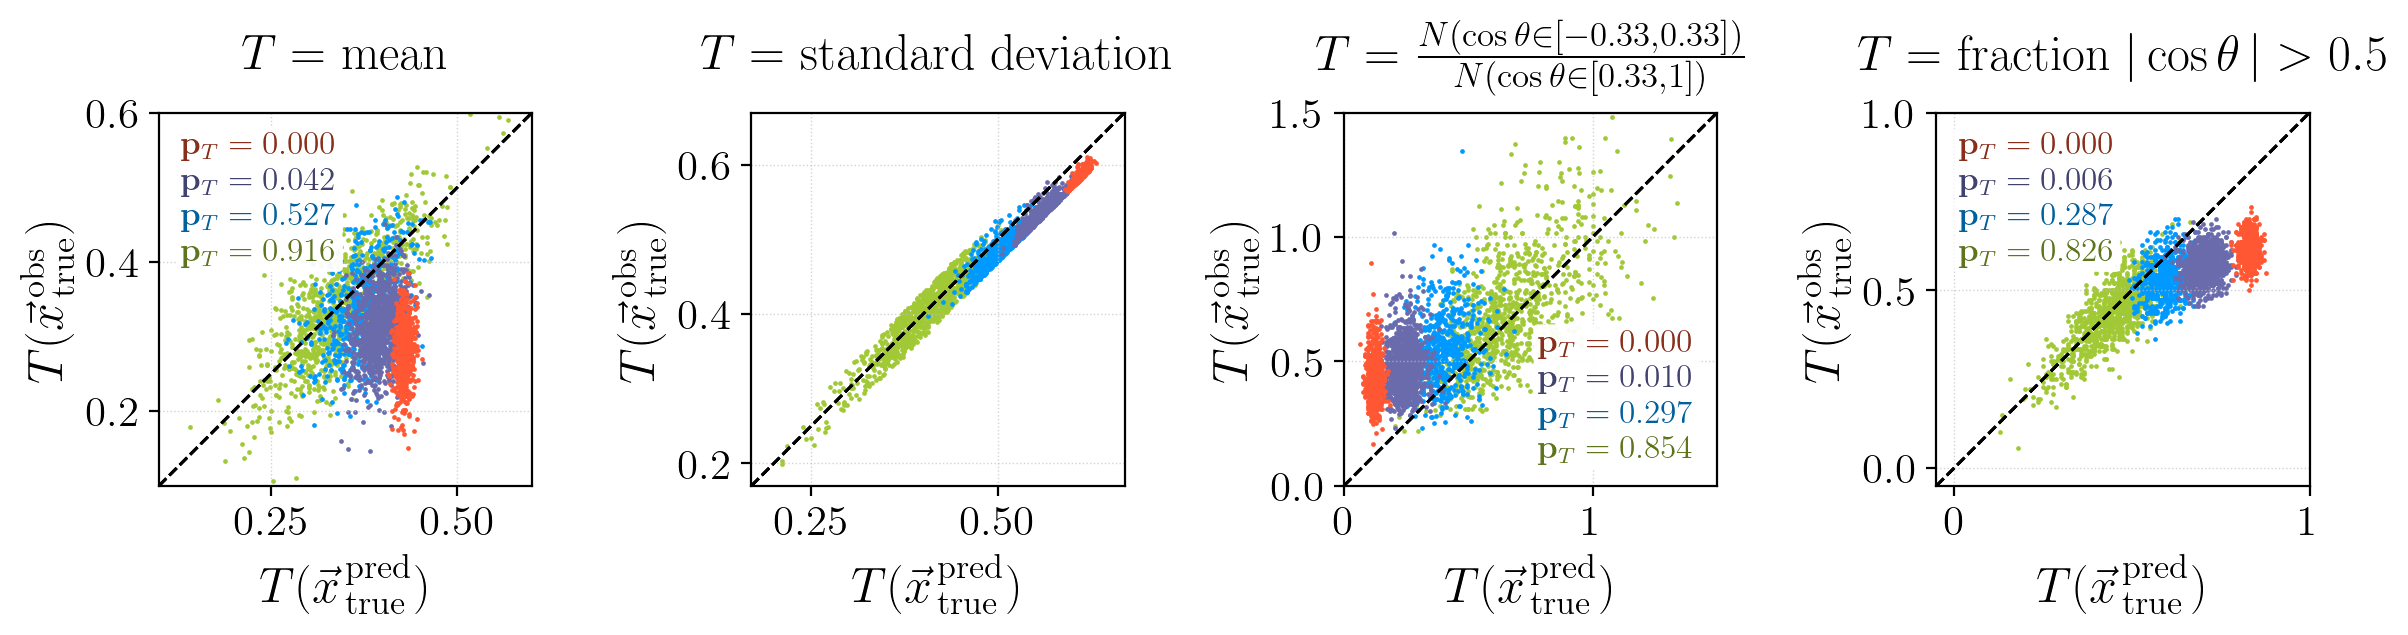

In [11]:
bounds_dict = {
    'mean':[0.1,0.6],
    'standard deviation':[0.17,0.67], 
    'minimum':[-1,0], 
    plot_utils.zp_title:[0,1.5],
    r'fraction $|\cos\theta\,|>0.5$':[-0.05,1]
}

fig, axes = plt.subplots(1,4,figsize=(12,3))

for j, (run, T_dict) in enumerate(T_dict_std_partial.items()):
    color = plot_utils.run_colors[run]
    pcolor = plot_utils.run_colors_darker[run]
    run_label = plot_utils.run_labels[run]
    
    for i, k in enumerate(T_dict.keys()): 

        ax_top = axes[i]
        ax_top.scatter(T_dict[k]['T'], T_dict[k]['Trep'], s=0.5, 
                   color=color, label=run_label, zorder=run_orders[run])
        
        diag = bounds_dict[k]
        ax_top.plot(diag, diag, color='k', lw=1, ls='--', zorder=5)
        ax_top.set_xlim(*diag)
        ax_top.set_ylim(*diag)
    
        p = T_dict[k]['pvalue']

        if i != 1:
            if i == 2: 
                ax_top.text(0.52, 0.42-j*0.095, fr'$\mathbf{{p}}_T={p:.3f}$', 
                        transform=ax_top.transAxes, color=pcolor, **text_kws)
            else:
                ax_top.text(0.06, 0.95-j*0.095, fr'$\mathbf{{p}}_T={p:.3f}$', 
                        transform=ax_top.transAxes, color=pcolor, **text_kws)
            
        ax_top.set_xlabel(r'$T(\vec{x}^{\,\mathrm{pred}}_{\,\mathrm{true}})$')
        ax_top.set_ylabel(r'$T(\vec{x}^{\,\mathrm{obs}}_{\,\mathrm{true}})$')
        ax_top.set_title(fr'$T=$ {k}',y=1.07)
        ax_top.set_box_aspect(1)

for ax in axes.flatten(): 
    ax.grid()
plt.tight_layout()

plt.savefig('figure_08b.png', dpi=300, bbox_inches='tight')
plt.show()

Split PC

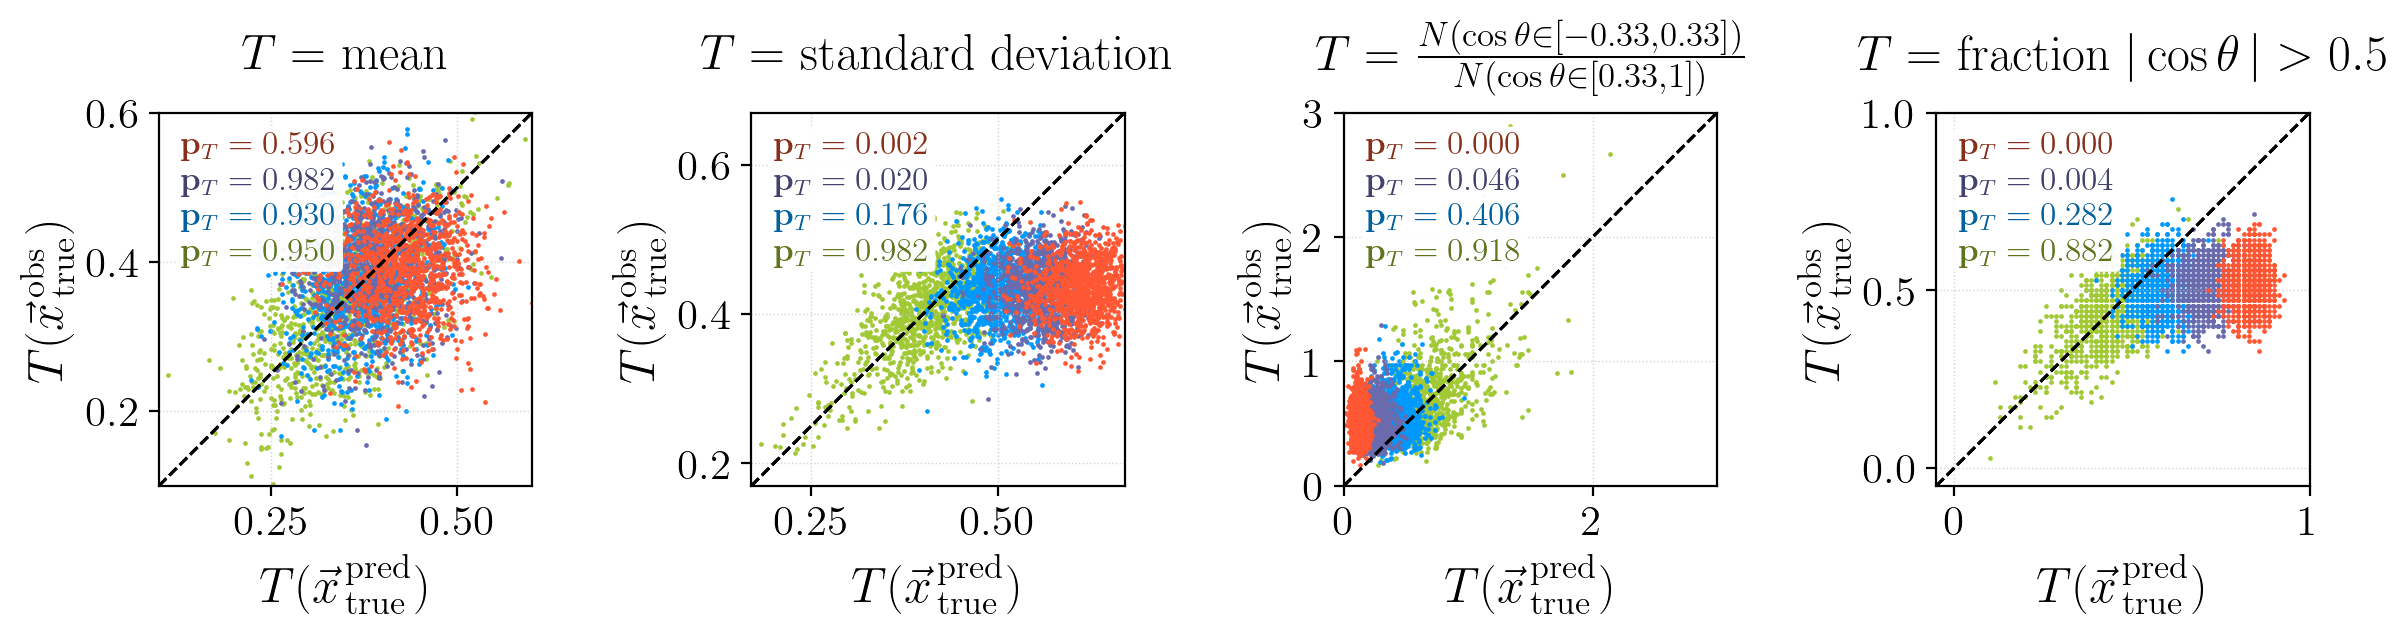

In [12]:
bounds_dict = {
    'mean':[0.1,0.6],
    'standard deviation':[0.17,0.67], 
    'minimum':[-1,0], 
    plot_utils.zp_title:[0,3],
    r'fraction $|\cos\theta\,|>0.5$':[-0.05,1]
}

fig, axes = plt.subplots(1,4,figsize=(12,3))

for j, (run, T_dict) in enumerate(T_dict_split.items()):
    color = plot_utils.run_colors[run]
    pcolor = plot_utils.run_colors_darker[run]
    run_label = plot_utils.run_labels[run]
    
    for i, k in enumerate(T_dict.keys()): 

        ax_top = axes[i]
        ax_top.scatter(T_dict[k]['T'], T_dict[k]['Trep'], s=0.5, 
                   color=color, label=run_label, zorder=run_orders[run])
        
        diag = bounds_dict[k]
        ax_top.plot(diag, diag, color='k', lw=1, ls='--', zorder=5)
        ax_top.set_xlim(*diag)
        ax_top.set_ylim(*diag)
    
        p = T_dict[k]['pvalue']

        ax_top.text(0.06, 0.95-j*0.095, fr'$\mathbf{{p}}_T={p:.3f}$', 
                        transform=ax_top.transAxes, color=pcolor, **text_kws)
            
        ax_top.set_xlabel(r'$T(\vec{x}^{\,\mathrm{pred}}_{\,\mathrm{true}})$')
        ax_top.set_ylabel(r'$T(\vec{x}^{\,\mathrm{obs}}_{\,\mathrm{true}})$')
        ax_top.set_title(fr'$T=$ {k}',y=1.07)
        ax_top.set_box_aspect(1)

for ax in axes.flatten(): 
    ax.grid()
plt.tight_layout()

plt.savefig('figure_09b.png', dpi=300, bbox_inches='tight')
plt.show()